In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [4]:
tips=sns.load_dataset('tips')

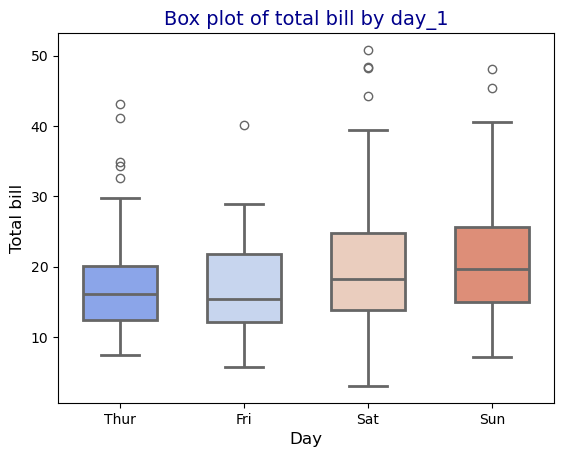

In [8]:
sns.boxplot(x='day',y='total_bill',data=tips,
            palette='coolwarm',
            width=0.6,
            linewidth=2, #line thickness
            fliersize=6 #size of outliers
           )
plt.title("Box plot of total bill by day_1",fontsize=14,color='darkblue')
plt.xlabel("Day",fontsize=12)
plt.ylabel("Total bill",fontsize=12)
plt.show()

In [13]:
# Five number summary & Outliers
Q1=tips['total_bill'].quantile(0.25)  #first half 
Q2=tips['total_bill'].median()       # median of complete data 
Q3=tips['total_bill'].quantile(0.75) #second half median
IQR=Q3-Q1
lower_wisker=Q1-1.5*IQR
upper_wisker=Q3+1.5*IQR

minimum=tips['total_bill'].min()
maximum=tips['total_bill'].max()

outliers=tips[(tips['total_bill']<lower_wisker)| (tips['total_bill']>upper_wisker)]['total_bill']
print('Box plot summary for total_bill')
print(f'Q1(25th percentaile):{Q1:.2f}')
print(f'Q2(50th percentaile):{Q2:.2f}')
print(f'Q3(25th percentaile):{Q3:.2f}')
print(f"IQR:{IQR:.2f}")
print(f"lower whisker:{lower_wisker:.2f}")
print(f"upper whisker:{upper_wisker:.2f}")
print(f'minimum value:{minimum:.2f}')
print(f'maximum value:{maximum:.2f}')
print(f'outliers:{list(outliers)}')

Box plot summary for total_bill
Q1(25th percentaile):13.35
Q2(50th percentaile):17.80
Q3(25th percentaile):24.13
IQR:10.78
lower whisker:-2.82
upper whisker:40.30
minimum value:3.07
maximum value:50.81
outliers:[48.27, 44.3, 41.19, 48.17, 50.81, 45.35, 40.55, 43.11, 48.33]


## Violin Plot

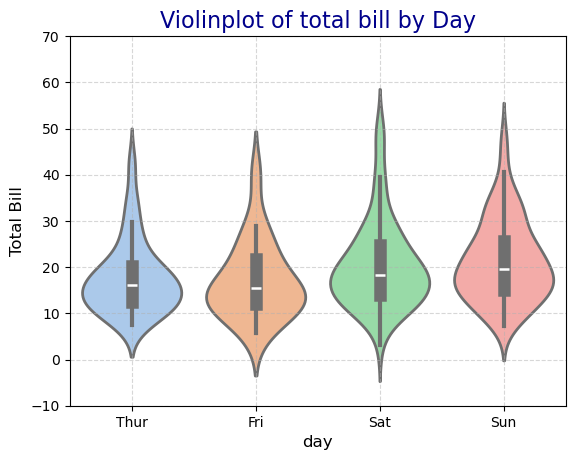

In [15]:
sns.violinplot(
    x='day',
    y='total_bill',
    data=tips,
    palette='pastel',
    inner='box',
    linewidth=2,
    scale='width'
)
plt.ylim(-10,70)
plt.xlabel("day",fontsize=12)
plt.ylabel("Total Bill", fontsize=12)
plt.title("Violinplot of total bill by Day",fontsize=16,color='darkblue')
plt.grid(True,linestyle='--',alpha=0.5)
plt.show()

# Scatter plot

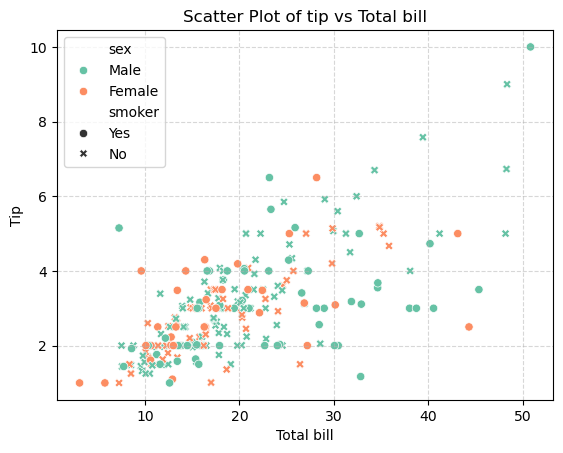

In [19]:
sns.scatterplot(
    x='total_bill',
    y='tip',
    data=tips,
    hue='sex' ,       #deferent by category (male/female)
    style='smoker',  #different style for smokers
    palette='Set2'
)
plt.title("Scatter Plot of tip vs Total bill")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.grid(True , linestyle='--',alpha=0.5)
plt.show()

## Line Plot

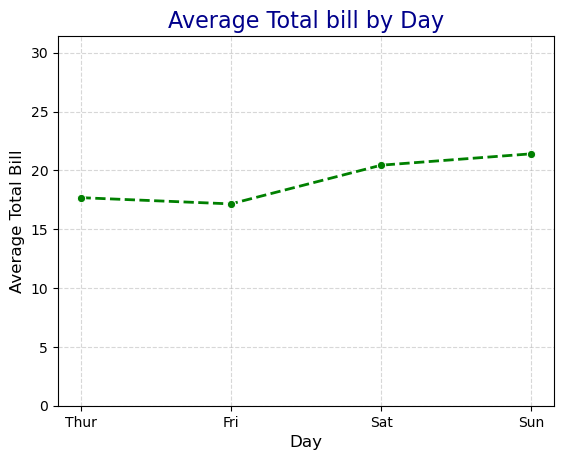

In [22]:
avg_total_bill=tips.groupby('day')['total_bill'].mean().reset_index()
sns.lineplot(
    x='day',
    y='total_bill',
    data=avg_total_bill,
    marker='o',
    linestyle='--',
    color='green',
    linewidth=2
)
plt.ylim(0,avg_total_bill['total_bill'].max()+10)
plt.title("Average Total bill by Day",fontsize=16,color='darkblue')
plt.xlabel("Day",fontsize=12)
plt.ylabel("Average Total Bill",fontsize=12)
plt.grid(True ,linestyle='--',alpha=0.5)


# Bar Plot

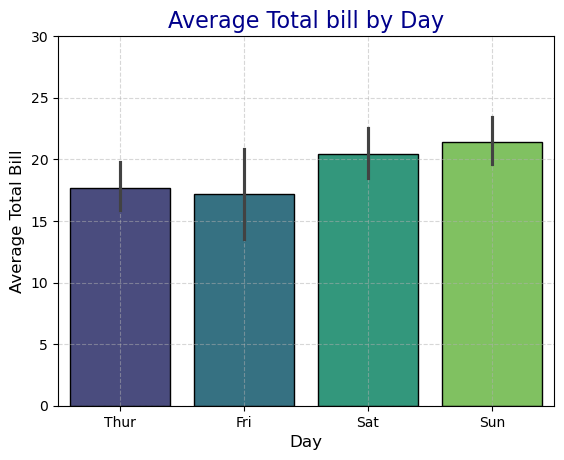

In [26]:
sns.barplot(
    x='day',
    y='total_bill',
    data=tips,
    palette='viridis',
    edgecolor='black'
)
plt.ylim(0,30)
plt.title("Average Total bill by Day",fontsize=16,color='darkblue')
plt.xlabel("Day",fontsize=12)
plt.ylabel("Average Total Bill",fontsize=12)
plt.grid(True ,linestyle='--',alpha=0.5)
plt.show()


# Pair Plot

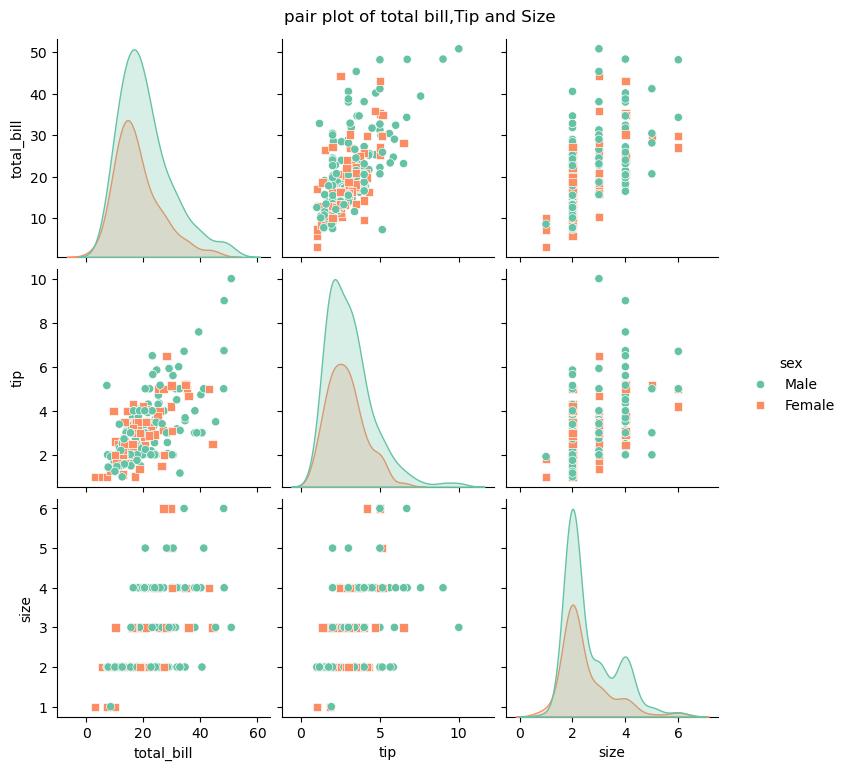

In [30]:
sns.pairplot(
    data=tips,
    vars=['total_bill','tip','size'],
    hue='sex',
    palette='Set2',
    diag_kind='kde',
    markers=['o','s']
)
plt.suptitle("pair plot of total bill,Tip and Size",y=1.02)
#suptitle=--->title for entire figure
plt.show()


# Heat map

In [31]:
numeric_data=tips.select_dtypes(include=['number'])
corr=numeric_data.corr()
corr

    

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000
